In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("titanic.csv")
print("Dataset Loaded successfully")
df.head()

Dataset Loaded successfully


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
#Clean Data with missing age value mean
mean_age = df['Age'].mean()
df['Age'] = df['Age'].fillna(mean_age)
print(f"Missing ages filled {mean_age:.2f}")

Missing ages filled 29.70


In [6]:
# dropping Cabin column because missing value to be useful
df = df.drop(columns=['Cabin'])
print("Cabin column dropped Successfully")


Cabin column dropped Successfully


In [7]:
df = df.dropna()
print(f"Final Dataset {df.shape}")

Final Dataset (889, 11)


In [8]:
#Creating Age group
bins = [0, 12, 18, 30, 50, 80]
labels = ['Child', 'Teens', 'YoungAdult', 'Adult', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [9]:
df[['Age', 'AgeGroup']].head()

,Age,AgeGroup
0,22.0,YoungAdult
1,38.0,Adult
2,26.0,YoungAdult
3,35.0,Adult
4,35.0,Adult


In [10]:
#Survival Rate by Age Group :-
age_survival = df.groupby('AgeGroup')['Survived'].mean() * 100
print("Survival Rate by Age Group: ")
print(age_survival)

Survival Rate by Age Group: 
AgeGroup
Child         57.971014
Teens         42.857143
YoungAdult    33.109620
Adult         42.083333
Senior        33.333333
Name: Survived, dtype: float64


C:\Users\Saurabh\AppData\Local\Temp\ipykernel_20216\2199709965.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = df.groupby('AgeGroup')['Survived'].mean() * 100


In [11]:
#Survival Rate by Embarkation Port:- 
port_survival = df.groupby('Embarked')['Survived'].mean() * 100
print("\nSurvival Rate by Embarkation Port (%): ") 
print(port_survival)



Survival Rate by Embarkation Port (%): 
Embarked
C    55.357143
Q    38.961039
S    33.695652
Name: Survived, dtype: float64


In [13]:
#Create Family Size and check survival:-
df['FamilySize'] = df['SibSp'] + df['Parch']
# Family Size = Siblings/Spouses (SibSp) + Parents/Children (Parch)
family_survival = df.groupby('FamilySize')['Survived'].mean() * 100
print("\nSurvival Rate by Family Size (%):")
print(family_survival)


Survival Rate by Family Size (%):
FamilySize
0     30.093458
1     55.279503
2     57.843137
3     72.413793
4     20.000000
5     13.636364
6     33.333333
7      0.000000
10     0.000000
Name: Survived, dtype: float64


In [14]:
# Visualizations:-
plt.figure(figsize=(18, 12))

<Figure size 1800x1200 with 0 Axes>

<Figure size 1800x1200 with 0 Axes>

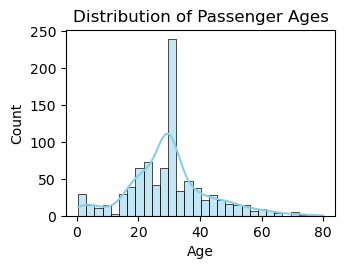

In [15]:
#Histogram:-
plt.subplot(2, 2, 1)
sns.histplot(df['Age'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

C:\Users\Saurabh\AppData\Local\Temp\ipykernel_20216\1287958756.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AgeGroup', y='Survived', data=df, palette='viridis')


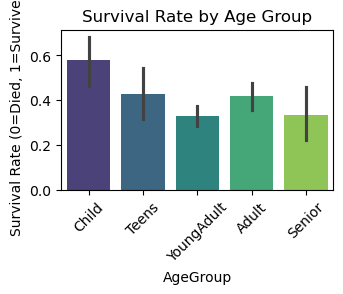

In [17]:
#Barplot:- By Age Group
plt.subplot(2, 2, 2)
sns.barplot(x='AgeGroup', y='Survived', data=df, palette='viridis')
plt.title('Survival Rate by Age Group')
plt.ylabel('Survival Rate (0=Died, 1=Survived)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

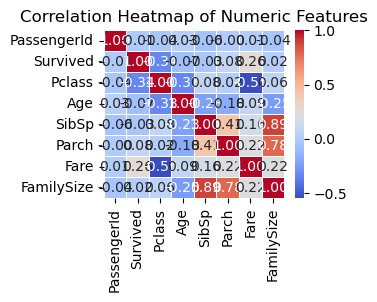

In [19]:
#Heatmap: Correlations between numeric columns
plt.subplot(2, 2, 3)
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

C:\Users\Saurabh\AppData\Local\Temp\ipykernel_20216\905885140.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='FamilySize', y='Survived', data=df, palette='magma')


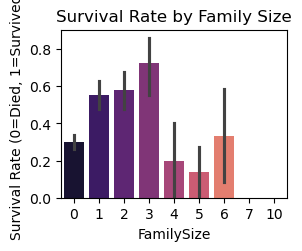

In [20]:
#Barplot: Survival by Family Size
plt.subplot(2, 2, 4)
sns.barplot(x='FamilySize', y='Survived', data=df, palette='magma')
plt.title('Survival Rate by Family Size')
plt.ylabel('Survival Rate (0=Died, 1=Survived)')
plt.show()